#### DecodeLabs Internship - Project 2
##### Exploratory Data Analysis (EDA)
##### Analyst: Norysca
##### Date: August 2026

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/content/Cleaned_Dataset_DecodeLabs_P1.csv')

print("Shape:", df.shape)
df.head()

Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


#####Basic Descriptive Statistics

In [5]:
print("Descriptive Statistics")
print(df[['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']].describe().round(2))

Descriptive Statistics
       Quantity  UnitPrice  TotalPrice  ItemsInCart
count   1200.00    1200.00     1200.00      1200.00
mean       2.95     356.41     1053.97         5.48
std        1.41     197.18      819.86         2.28
min        1.00      11.39       11.39         1.00
25%        2.00     186.06      410.52         4.00
50%        3.00     364.21      823.62         5.00
75%        4.00     521.57     1578.48         7.00
max        5.00     699.93     3456.40        10.00


#####Checking Sales by Product

In [6]:
product_revenue = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False).round(2)
print("Total Revenue By Product")
print(product_revenue)

Total Revenue By Product
Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64


#####Checking Sales by Order Status

In [7]:
status_counts = df['OrderStatus'].value_counts()
print("Order Status Distribution")
print(status_counts)
print("\nPercentage:")
print((status_counts / len(df) * 100).round(2))

Order Status Distribution
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

Percentage:
OrderStatus
Cancelled    20.83
Returned     20.58
Pending      19.75
Shipped      19.58
Delivered    19.25
Name: count, dtype: float64


#####Checking Revenue by Payment Method

In [8]:
payment_analysis = df.groupby('PaymentMethod').agg(
    Order_Count=('OrderID', 'count'),
    Total_Revenue=('TotalPrice', 'sum')
).round(2).sort_values('Total_Revenue',ascending=False)

print("Payment Method Analysis")
print(payment_analysis)

Payment Method Analysis
               Order_Count  Total_Revenue
PaymentMethod                            
Credit Card            234      263847.63
Online                 258      262442.94
Cash                   246      259786.29
Gift Card              230      246323.92
Debit Card             232      232361.18


#####Checking Top Referral Sources

In [9]:
referral = df.groupby('ReferralSource').agg(
    Order_Count=('OrderID', 'count'),
    Total_Revenue=('TotalPrice','sum')
).round(2).sort_values('Order_Count', ascending=False)

print("Referral Source Analysis")
print(referral)

Referral Source Analysis
                Order_Count  Total_Revenue
ReferralSource                            
Instagram               259      275285.45
Email                   250      261808.55
Google                  241      250441.48
Facebook                228      250410.90
Referral                222      226815.58


#####Detecting Outliers using IQR method

In [14]:
Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)
IQR = Q3-Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]

print("OUTLIER DETECTION - TotalPrice")
print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Number of Outliers: {len(outliers)}")
print(outliers[['OrderID', 'Product', 'Quantity', 'UnitPrice', 'TotalPrice']].head(10))

OUTLIER DETECTION - TotalPrice
Q1: 410.52
Q3: 1578.475
IQR: 1167.955
Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8
        OrderID  Product  Quantity  UnitPrice  TotalPrice
107   ORD200107  Printer         5     670.75     3353.75
326   ORD200326   Laptop         5     670.48     3352.40
328   ORD200328   Tablet         5     674.04     3370.20
469   ORD200469    Chair         5     676.98     3384.90
632   ORD200632   Laptop         5     678.16     3390.80
789   ORD200789   Tablet         5     691.28     3456.40
1065  ORD201065  Printer         5     666.80     3334.00
1122  ORD201122  Monitor         5     678.19     3390.95


######Visualizing through charts

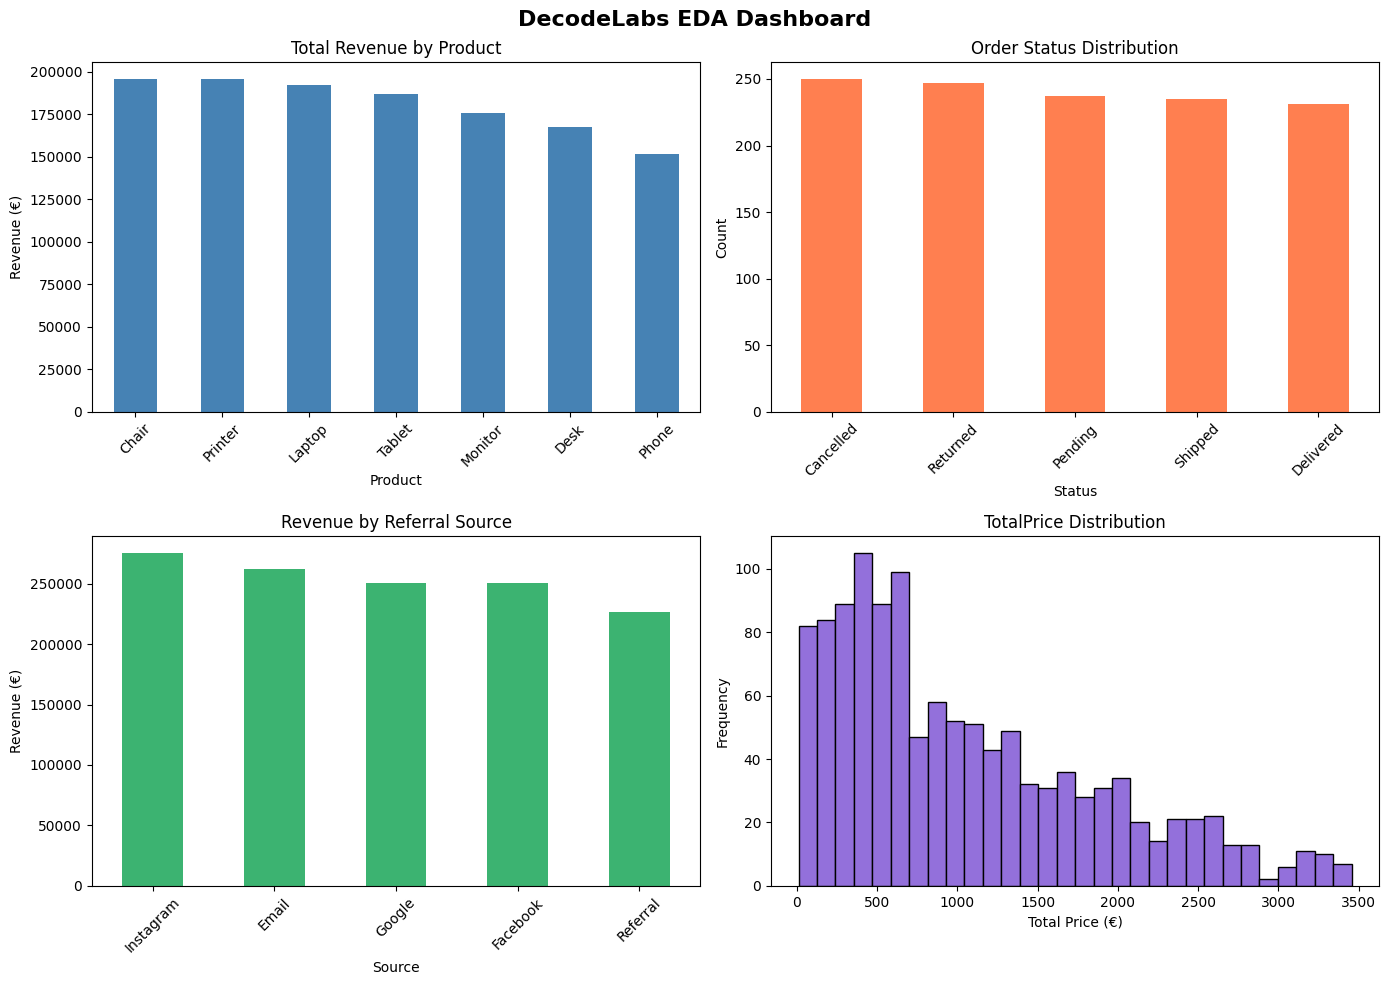

Dashboard saved!


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('DecodeLabs EDA Dashboard', fontsize=16, fontweight='bold')

#Chart 1 - Revenue by Product
product_revenue.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Revenue by Product')
axes[0,0].set_xlabel('Product')
axes[0,0].set_ylabel('Revenue (€)')
axes[0,0].tick_params(axis='x', rotation=45)

#Chart 2 - Order Status Distribution
status_counts.plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Order Status Distribution')
axes[0,1].set_xlabel('Status')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=45)

#Chart 3 - Revenue by Referral Source
referral['Total_Revenue'].plot(kind='bar', ax=axes[1,0], color='mediumseagreen')
axes[1,0].set_title('Revenue by Referral Source')
axes[1,0].set_xlabel('Source')
axes[1,0].set_ylabel('Revenue (€)')
axes[1,0].tick_params(axis='x', rotation=45)

#Chart 4 - TotalPrice Distribution
axes[1,1].hist(df['TotalPrice'], bins=30, color='mediumpurple', edgecolor='black')
axes[1,1].set_title('TotalPrice Distribution')
axes[1,1].set_xlabel('Total Price (€)')
axes[1,1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('EDA_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved!")

#####Summary

In [16]:
print("""
=== EDA SUMMARY - KEY OBSERVATIONS ===

1. REVENUE INSIGHT:
   Chair (€195,620) and Printer (€195,612) are top revenue products.
   Phone generates the least revenue (€151,722) despite being common.

2. CRITICAL BUSINESS PROBLEM:
   Only 19.25% of orders are Delivered successfully.
   41.4% of orders are Cancelled or Returned — significant revenue loss.

3. MARKETING INSIGHT:
   Instagram is the #1 acquisition channel (259 orders, €275,285).
   Referral programme is weakest (222 orders, €226,815).

4. PAYMENT INSIGHT:
   Credit Card generates highest revenue (€263,847).
   Online payment is most popular by order count (258 orders).

5. OUTLIER INSIGHT:
   8 high-value orders detected (€3,334 - €3,456).
   All are Quantity=5 purchases of premium products.
   Likely VIP/corporate buyers — worth targeting.

6. DISTRIBUTION INSIGHT:
   TotalPrice is right-skewed — mean (€1,053) > median (€823).
   Most customers spend under €1,000 per order.
""")


=== EDA SUMMARY - KEY OBSERVATIONS ===

1. REVENUE INSIGHT:
   Chair (€195,620) and Printer (€195,612) are top revenue products.
   Phone generates the least revenue (€151,722) despite being common.

2. CRITICAL BUSINESS PROBLEM:
   Only 19.25% of orders are Delivered successfully.
   41.4% of orders are Cancelled or Returned — significant revenue loss.

3. MARKETING INSIGHT:
   Instagram is the #1 acquisition channel (259 orders, €275,285).
   Referral programme is weakest (222 orders, €226,815).

4. PAYMENT INSIGHT:
   Credit Card generates highest revenue (€263,847).
   Online payment is most popular by order count (258 orders).

5. OUTLIER INSIGHT:
   8 high-value orders detected (€3,334 - €3,456).
   All are Quantity=5 purchases of premium products.
   Likely VIP/corporate buyers — worth targeting.

6. DISTRIBUTION INSIGHT:
   TotalPrice is right-skewed — mean (€1,053) > median (€823).
   Most customers spend under €1,000 per order.



In [17]:
from google.colab import files
files.download('EDA_Dashboard.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>